In [1]:
import random
import numpy as np
from pathlib import Path
from the_well.data import WellDataset

import torch
from torch.utils.data import DataLoader

from modules import *
from losses import *
from datasets import TRMDataset
from vis_tools import *

In [ ]:
SEED         = 42
EPOCHS       = 20
BATCH_SIZE   = 64
LR           = 3e-3

BASE_PATH = "/mnt/storage_C1/BILL_pino"
DATASET_NAME = "NavierStokes_V1"
DATASET_PATH = BASE_PATH + "/external_ds/" + DATASET_NAME
OUTPUT_DIR   = BASE_PATH + '/models/' + DATASET_NAME

MODES1       = 16   # Modos de Fourier na primeira dimensão espacial (x)
MODES2       = 16   # Modos de Fourier na segunda dimensão espacial (y)
WIDTH        = 32   # Número de canais internos (largura do modelo)
DEPTH        = 4    # Quantidade de camadas de Fourier
PROJ_DIM     = 128  # Dimensão da MLP de projeção para a saída

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

Dispositivo: cuda
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128


In [4]:
train_dataset = WellDataset(
    path=DATASET_PATH,
    well_split_name="train"
)

validation_dataset = WellDataset(
    path=DATASET_PATH,
    well_split_name="valid"
)

train_ds = TRMDataset(train_dataset)
val_ds = TRMDataset(validation_dataset)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=4,
)

Epoch 1/20: 100%|██████████| 113/113 [00:40<00:00,  2.76it/s, loss=0.944763]


Epoch 001 | train = 0.944763 | val = 0.728265 | best_val = 0.728265


Epoch 2/20: 100%|██████████| 113/113 [00:37<00:00,  3.05it/s, loss=0.253790]


Epoch 002 | train = 0.253790 | val = 0.146969 | best_val = 0.146969


Epoch 3/20: 100%|██████████| 113/113 [00:38<00:00,  2.96it/s, loss=0.135166]


...

Epoch 018 | train = 0.103784 | val = 0.108650 | best_val = 0.108650


Epoch 19/20: 100%|██████████| 113/113 [00:37<00:00,  2.98it/s, loss=0.103251]


Epoch 019 | train = 0.103251 | val = 0.108255 | best_val = 0.108255


Epoch 20/20: 100%|██████████| 113/113 [00:38<00:00,  2.94it/s, loss=0.102861]


Epoch 020 | train = 0.102861 | val = 0.108093 | best_val = 0.108093


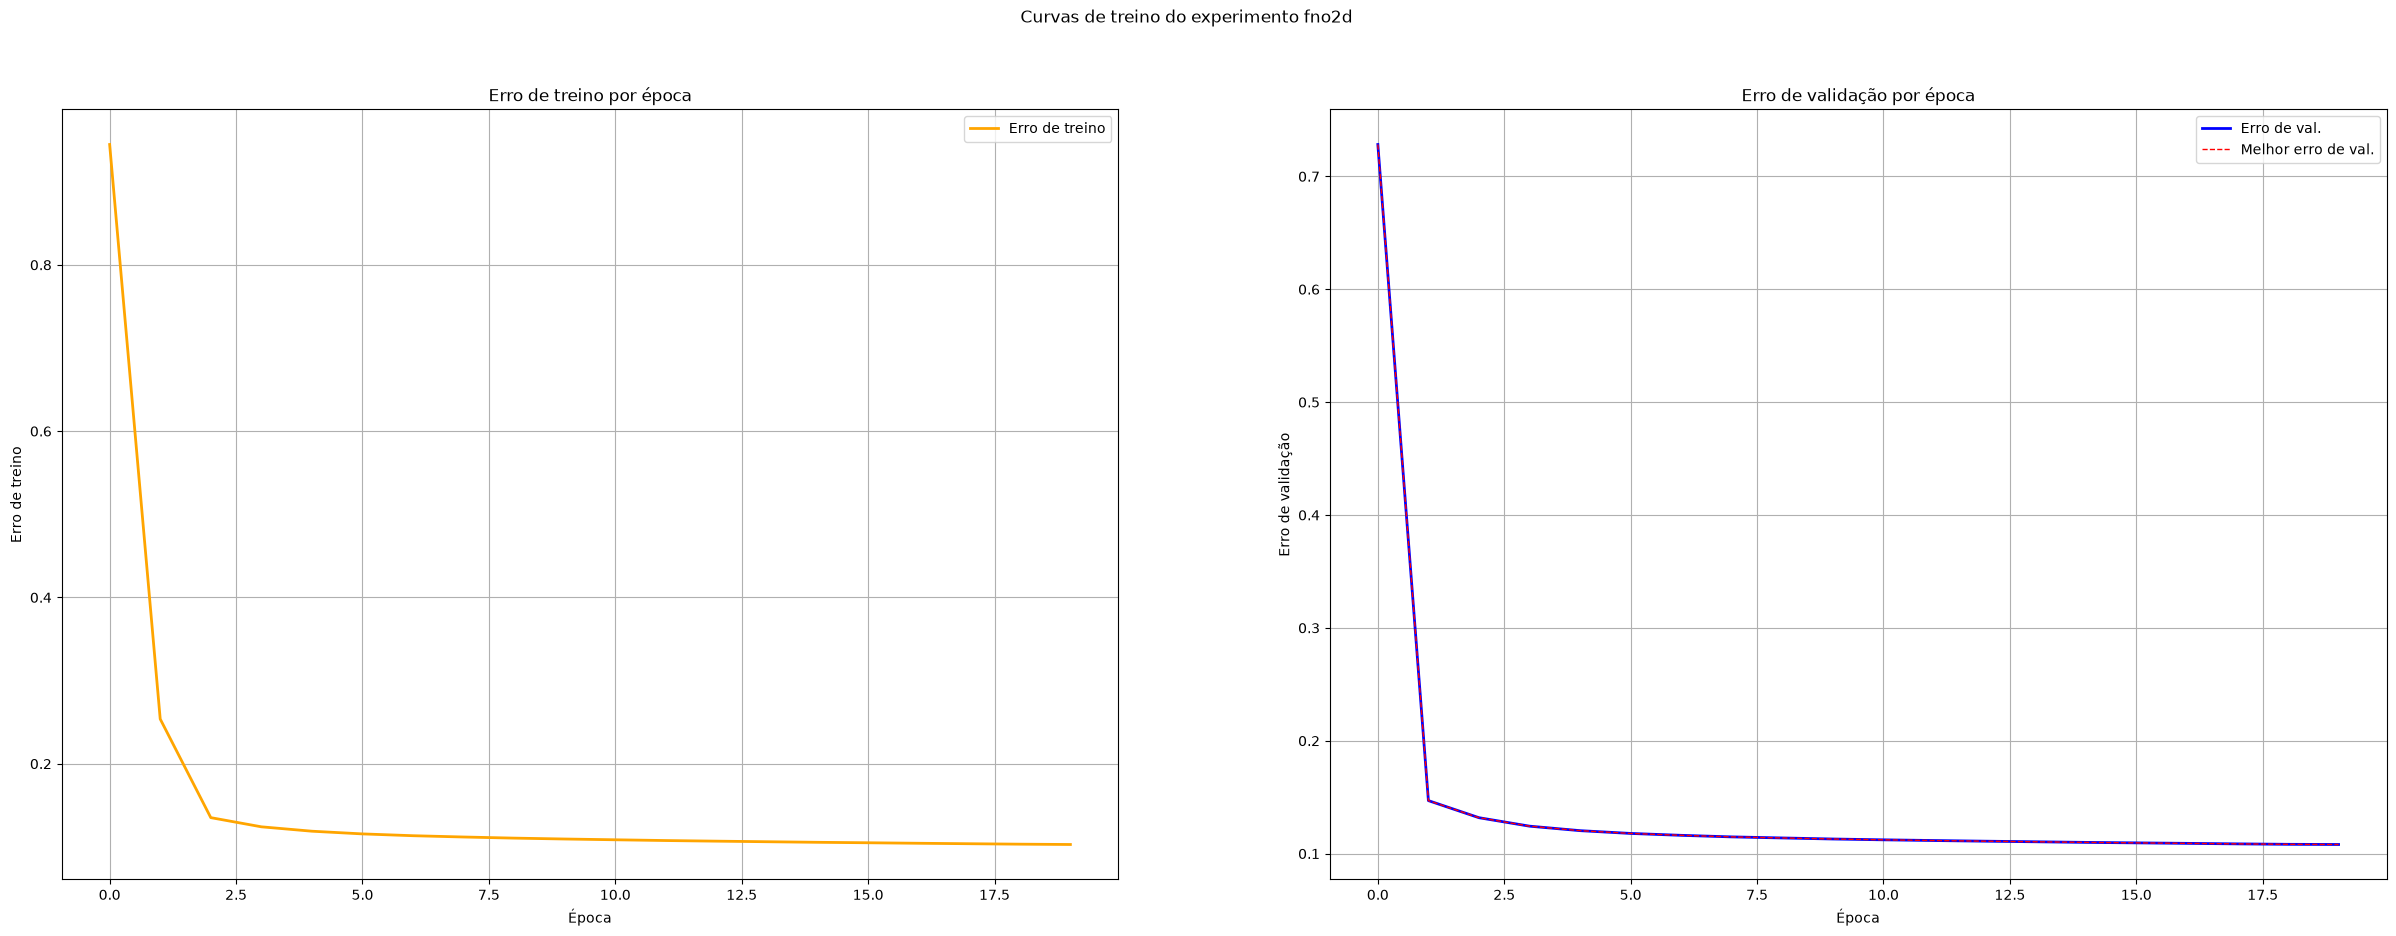

Epoch 1/20: 100%|██████████| 113/113 [00:51<00:00,  2.18it/s, loss=0.991549]


Epoch 001 | train = 0.991549 | val = 0.984036 | best_val = 0.984036


Epoch 2/20: 100%|██████████| 113/113 [00:43<00:00,  2.60it/s, loss=0.973743]


Epoch 002 | train = 0.973743 | val = 0.961325 | best_val = 0.961325


Epoch 3/20: 100%|██████████| 113/113 [00:43<00:00,  2.60it/s, loss=0.944688]


...

Epoch 018 | train = 0.097656 | val = 0.103519 | best_val = 0.103519


Epoch 19/20: 100%|██████████| 113/113 [00:40<00:00,  2.77it/s, loss=0.096930]


Epoch 019 | train = 0.096930 | val = 0.102915 | best_val = 0.102915


Epoch 20/20: 100%|██████████| 113/113 [00:41<00:00,  2.75it/s, loss=0.095892]


Epoch 020 | train = 0.095892 | val = 0.102328 | best_val = 0.102328


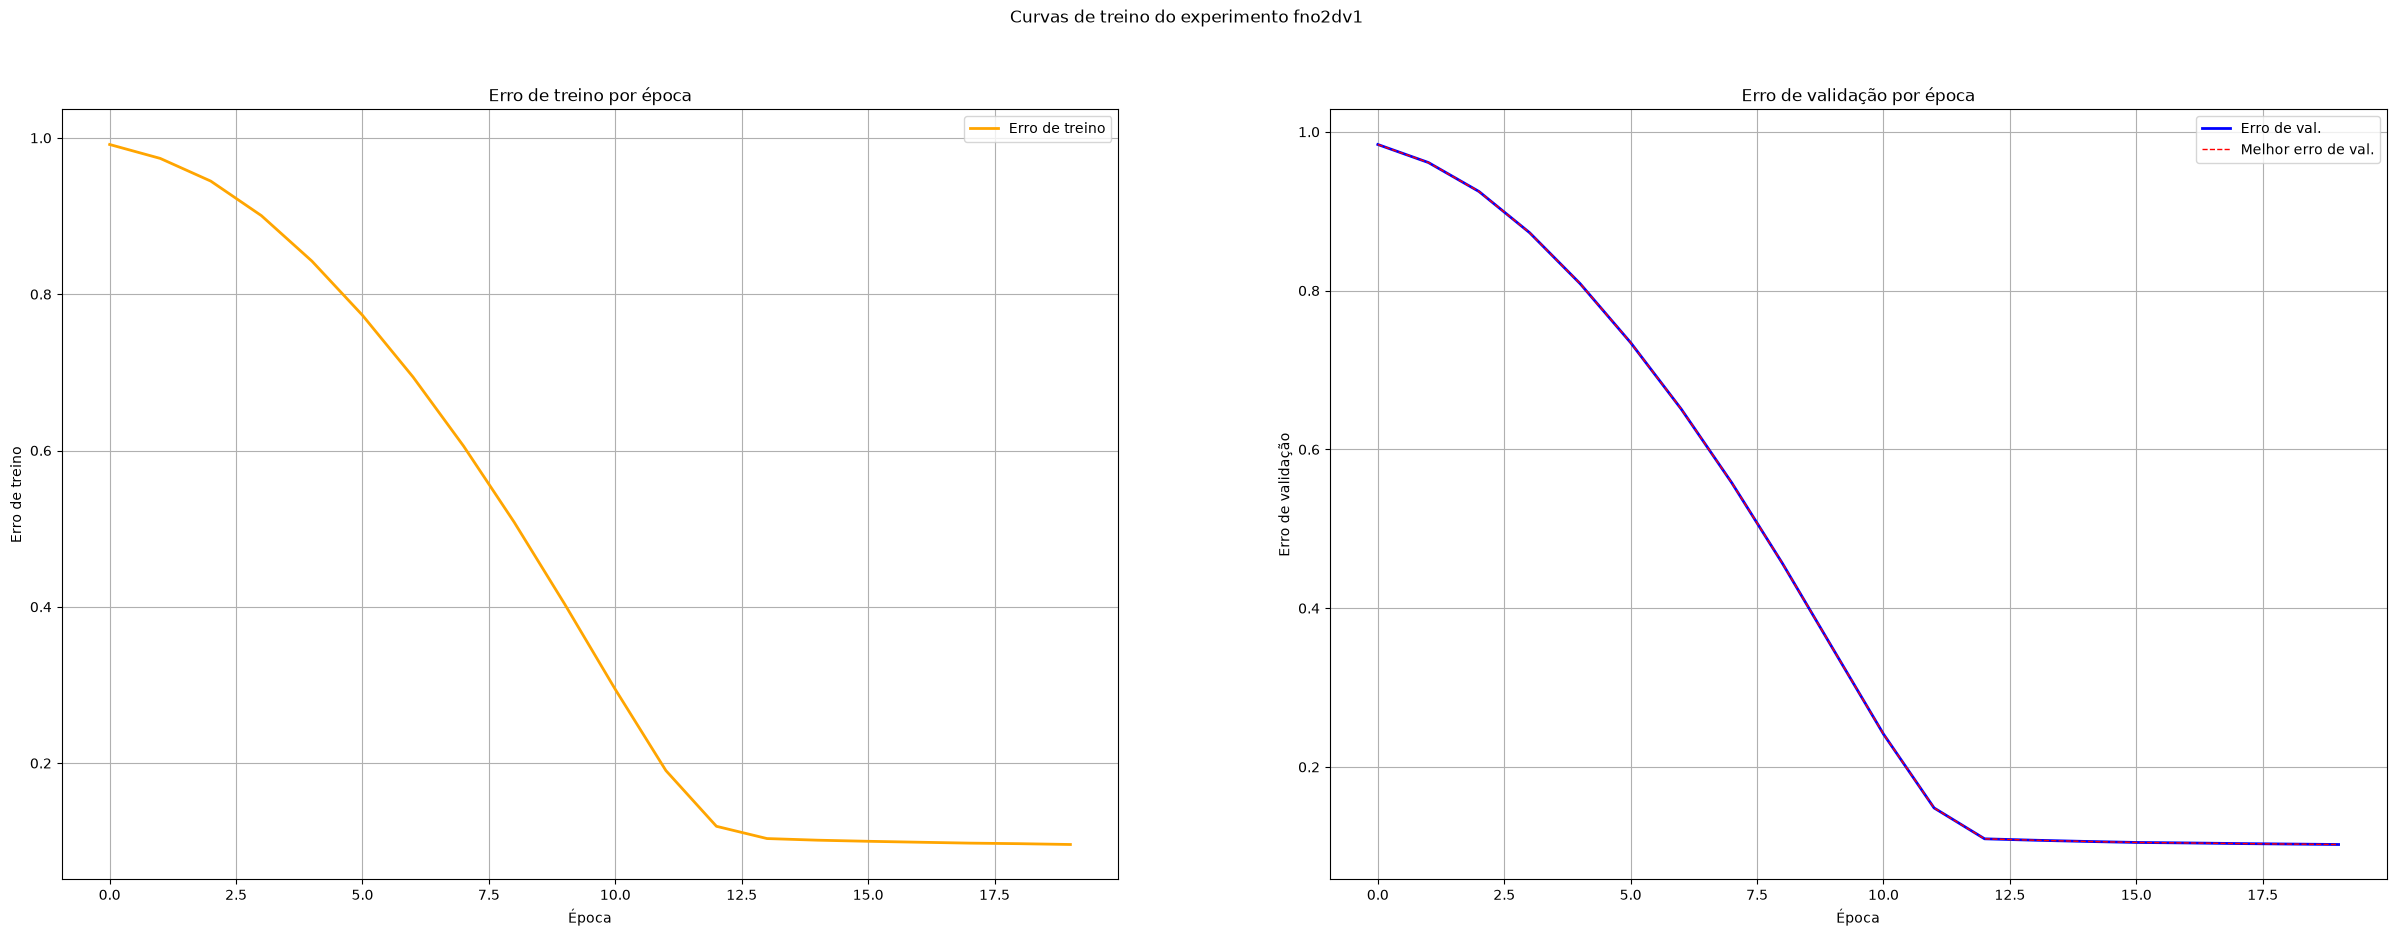

Epoch 1/20: 100%|██████████| 113/113 [00:55<00:00,  2.04it/s, loss=0.968548]


Epoch 001 | train = 0.968548 | val = 0.930268 | best_val = 0.930268


Epoch 2/20: 100%|██████████| 113/113 [00:54<00:00,  2.08it/s, loss=0.692717]


Epoch 002 | train = 0.692717 | val = 0.180445 | best_val = 0.180445


Epoch 3/20: 100%|██████████| 113/113 [00:52<00:00,  2.16it/s, loss=0.146282]


...

Epoch 018 | train = 0.093432 | val = 0.106716 | best_val = 0.106716


Epoch 19/20: 100%|██████████| 113/113 [00:49<00:00,  2.27it/s, loss=0.092487]


Epoch 019 | train = 0.092487 | val = 0.106778 | best_val = 0.106716


Epoch 20/20: 100%|██████████| 113/113 [00:49<00:00,  2.28it/s, loss=0.091318]


Epoch 020 | train = 0.091318 | val = 0.106879 | best_val = 0.106716


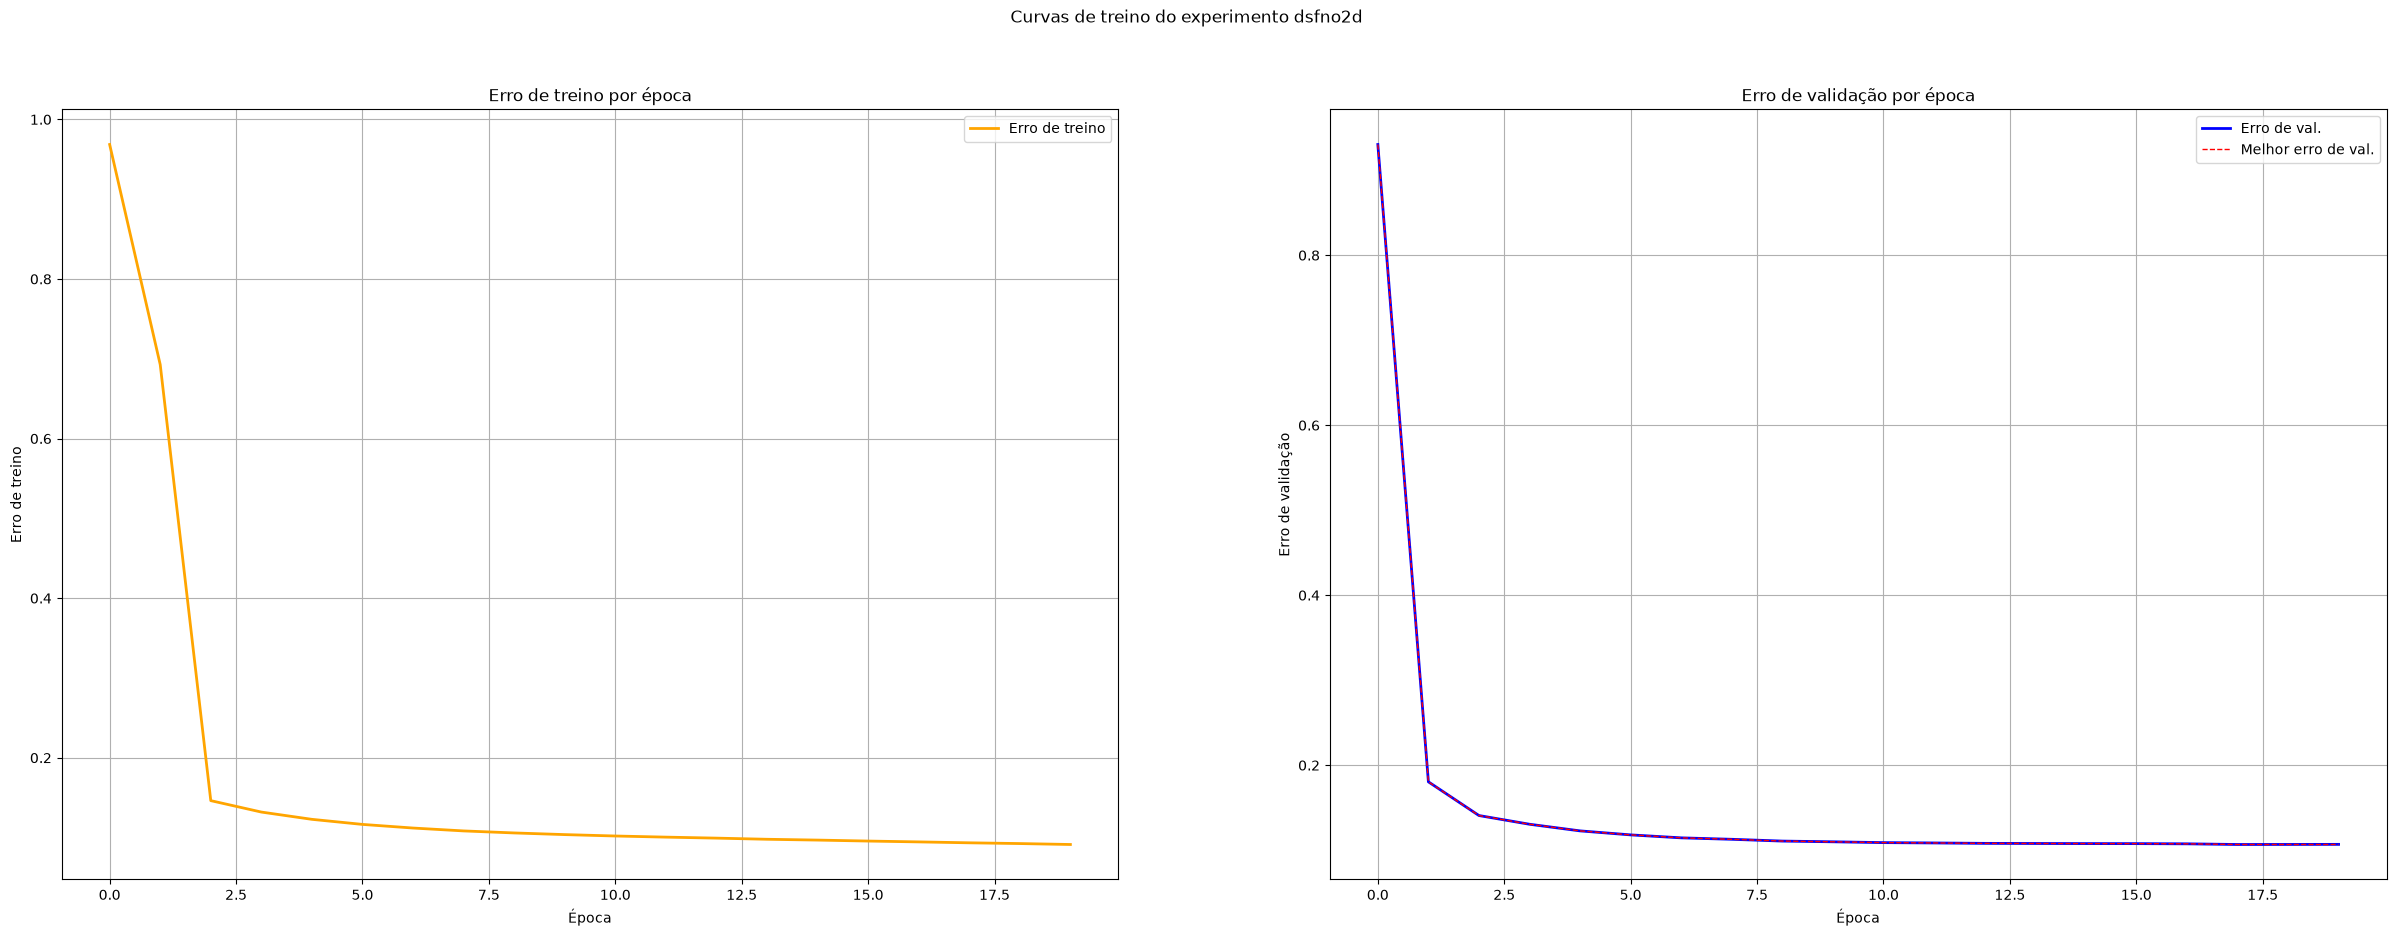

Epoch 1/20:   0%|          | 0/113 [00:00<?, ?it/s]/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/torch/_inductor/lowering.py:2212: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
W0628 11:18:17.875000 15557 torch/_inductor/utils.py:1731] [3/0] Not enough SMs to use max_autotune_gemm mode
Epoch 1/20: 100%|██████████| 113/113 [01:04<00:00,  1.75it/s, loss=0.609529]


Epoch 001 | train = 0.609529 | val = 0.232964 | best_val = 0.232964


Epoch 2/20: 100%|██████████| 113/113 [00:52<00:00,  2.14it/s, loss=0.196670]


Epoch 002 | train = 0.196670 | val = 0.191117 | best_val = 0.191117


Epoch 3/20: 100%|██████████| 113/113 [00:51<00:00,  2.18it/s, loss=0.183796]


...

Epoch 018 | train = 0.108279 | val = 0.116876 | best_val = 0.116876


Epoch 19/20: 100%|██████████| 113/113 [00:51<00:00,  2.21it/s, loss=0.107064]


Epoch 019 | train = 0.107064 | val = 0.116565 | best_val = 0.116565


Epoch 20/20: 100%|██████████| 113/113 [00:51<00:00,  2.21it/s, loss=0.106142]


Epoch 020 | train = 0.106142 | val = 0.116312 | best_val = 0.116312


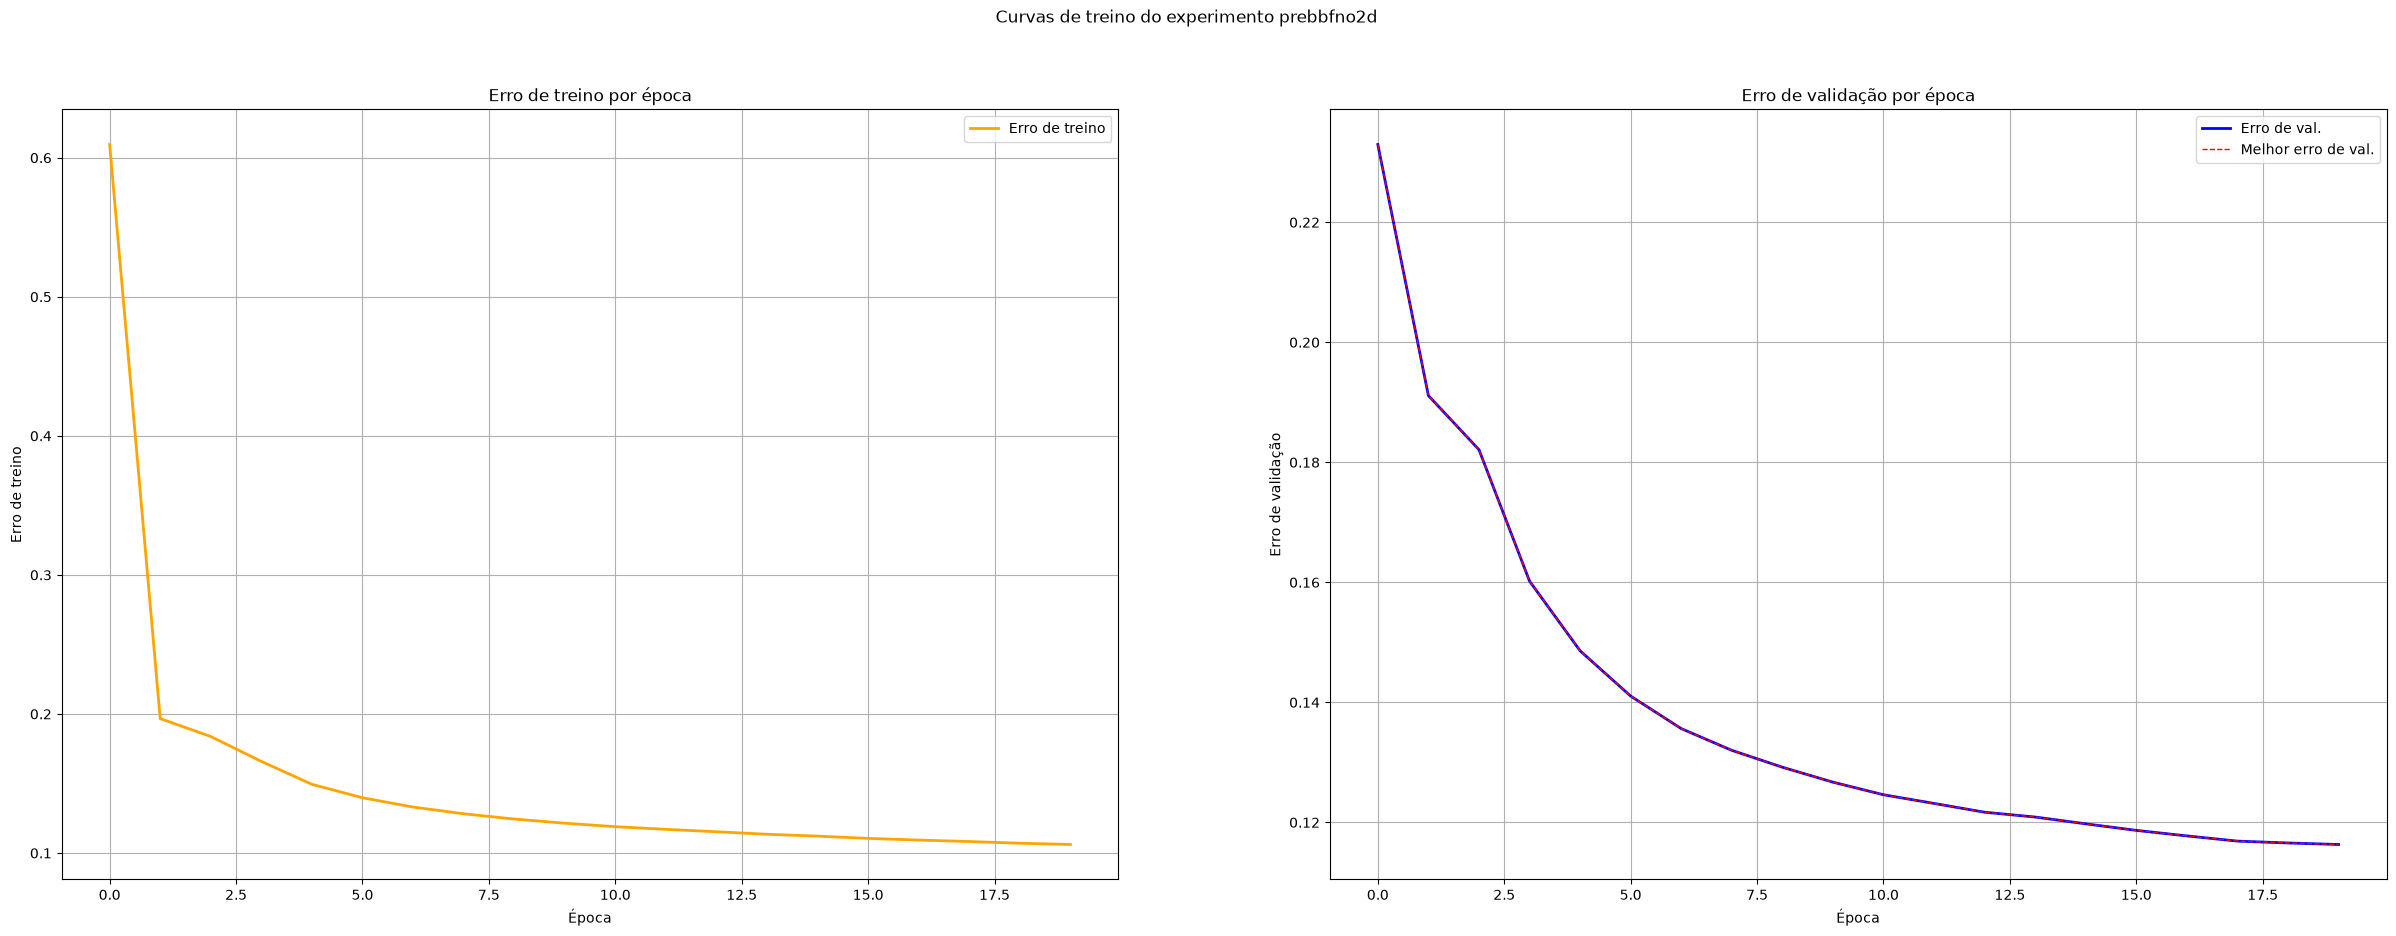

Epoch 1/20: 100%|██████████| 113/113 [01:00<00:00,  1.87it/s, loss=0.697386]


Epoch 001 | train = 0.697386 | val = 0.258505 | best_val = 0.258505


Epoch 2/20: 100%|██████████| 113/113 [00:55<00:00,  2.04it/s, loss=0.212053]


Epoch 002 | train = 0.212053 | val = 0.202949 | best_val = 0.202949


Epoch 3/20: 100%|██████████| 113/113 [00:53<00:00,  2.12it/s, loss=0.188560]


...

Epoch 018 | train = 0.108286 | val = 0.116821 | best_val = 0.116821


Epoch 19/20: 100%|██████████| 113/113 [00:53<00:00,  2.11it/s, loss=0.107106]


Epoch 019 | train = 0.107106 | val = 0.116038 | best_val = 0.116038


Epoch 20/20: 100%|██████████| 113/113 [00:51<00:00,  2.18it/s, loss=0.105932]


Epoch 020 | train = 0.105932 | val = 0.115400 | best_val = 0.115400


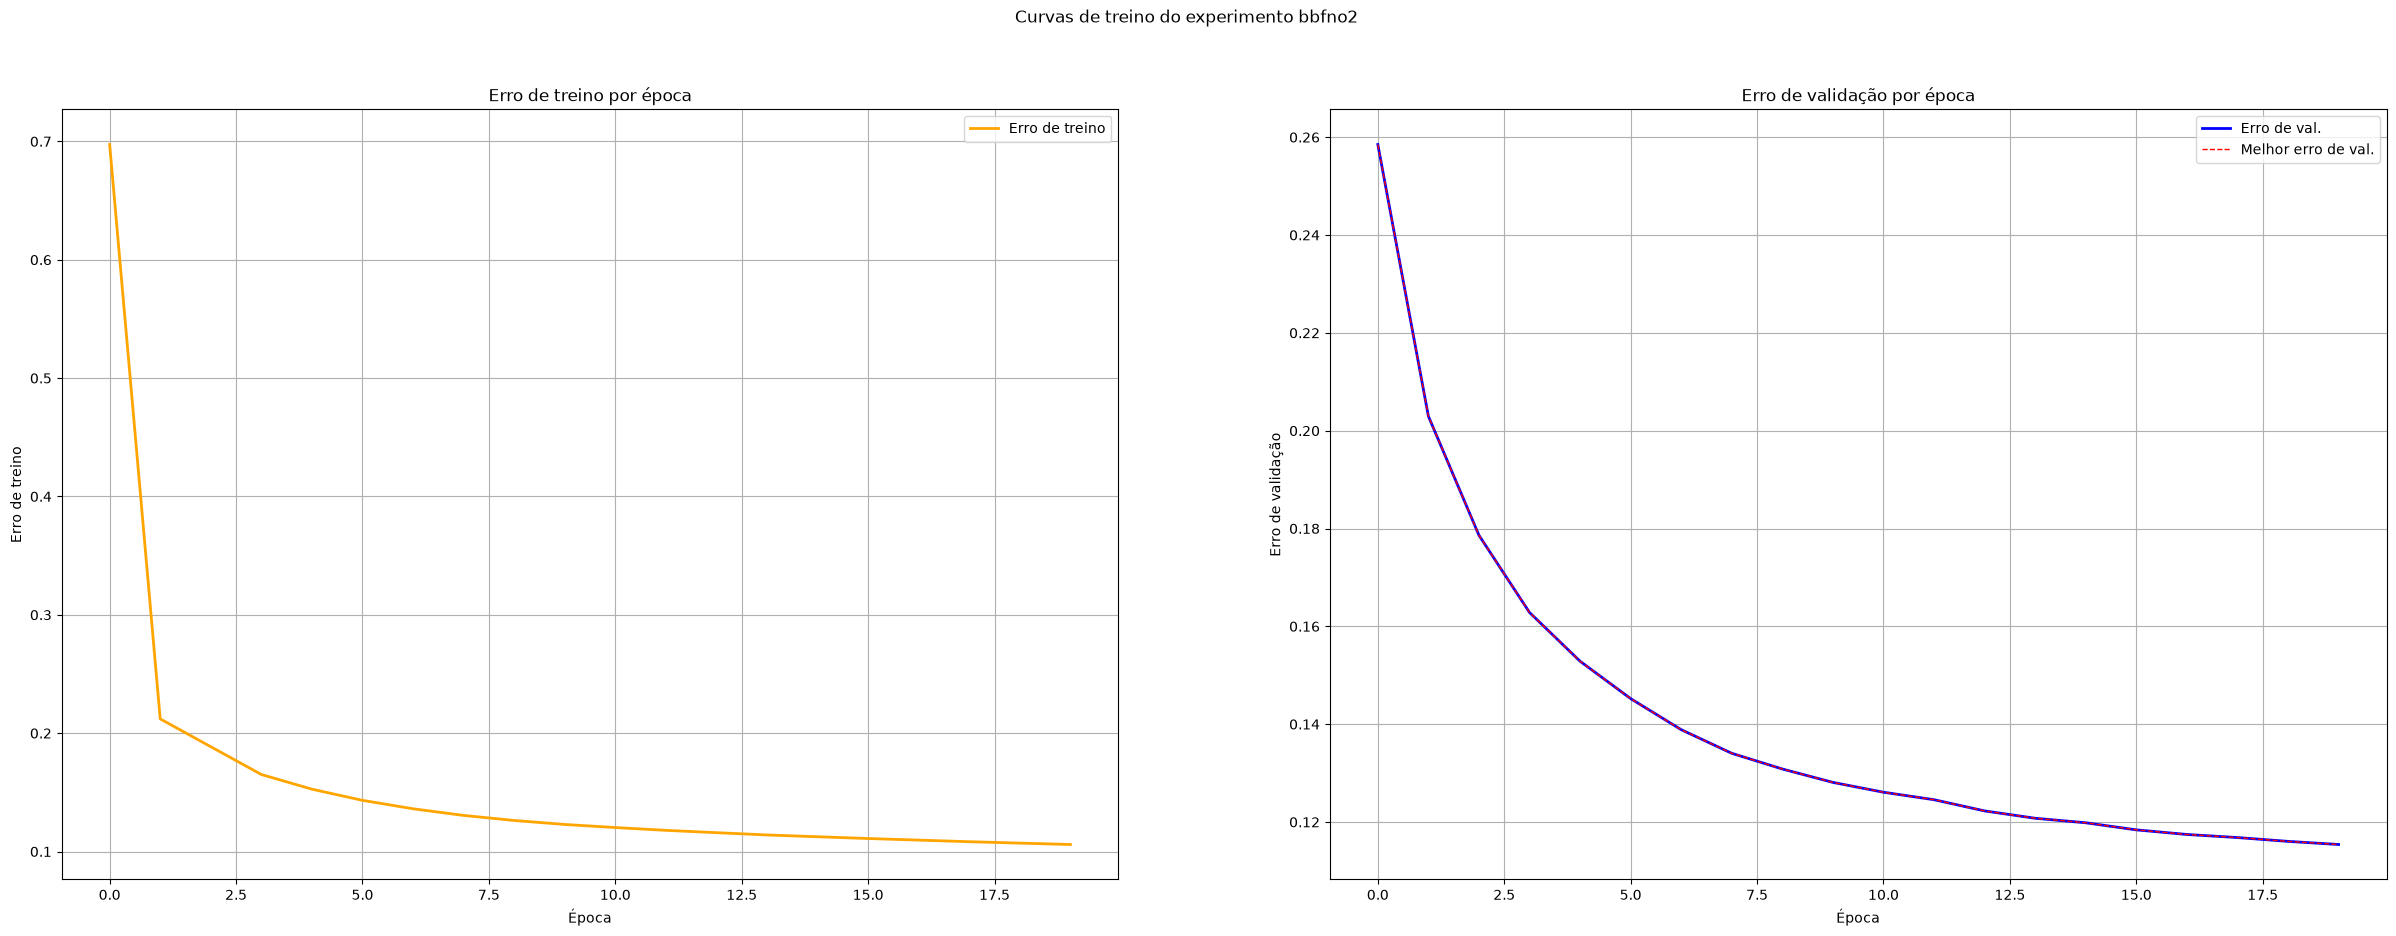

: 

In [ ]:
NUM_EXPS = 5

experiments = {
    'experiment_name': ['fno2d',"fno2dv1","dsfno2d","prebbfno2d","bbfno2"],
    'experiment_model': [FNO2d, FNO2d_v1, DoubleSkipFNO2d, BackbonePreFNO2d, BackboneFNO2d],
    'experiment_label': ['fno2d',"fno2dv1","dsfno2d","prebbfno2d","bbfno2"],
}

specifications = ['e-3_N5000_T50', 'e-4_N10000_T30']

x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

for i in range(NUM_EXPS):

    if i > 1:
        model = experiments['experiment_model'][i](
        modes1=MODES1,
        modes2=MODES2,
        width=WIDTH,
        in_dim=in_dim,
        out_dim=out_dim,
        depth=DEPTH,
        proj_dim=PROJ_DIM,
        mlp_width=421
    ).cuda()

    else:
        model = experiments['experiment_model'][i](
            modes1=MODES1,
            modes2=MODES2,
            width=WIDTH,
            in_dim=in_dim,
            out_dim=out_dim,
            depth=DEPTH,
            proj_dim=PROJ_DIM
        ).cuda()

    model = torch.compile(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
    )

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=LR, 
        steps_per_epoch=len(train_loader), 
        epochs=EPOCHS,
        pct_start=0.2,
        anneal_strategy='cos'
    )

    criterion = relative_l2_loss

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        epochs=EPOCHS,
        checkpoint_dir=OUTPUT_DIR,
        label=experiments['experiment_label'][i]
    )

    train_vis = plot(history, OUTPUT_DIR + '/plots/' + experiments['experiment_label'][i], experiments['experiment_label'][i])

    train_vis.show(save=True)

    model_vis = gif(val_ds, model, experiments['experiment_label'][i], device, OUTPUT_DIR + '/gifs/' + experiments['experiment_label'][i])

    model_vis.show(steps=200)g


    